<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº 1 - SÍNTESIS Y OPERACIONES DE SEÑALES 
#### HOFFENREICH JULIETA


## Introducción

Durante este trabajo, para la resolución del **Ejercicio 1**, se sintetizaron y analizaron distintas señales discretas utilizando Python, manteniendo una longitud de $N=1000$ muestras. Se generaron señales sinusoidales, secuencias de ruido con distintas distribuciones estadísticas y una señal rectangular periódica. Para cada caso se estudió su representación en el dominio temporal y el módulo de su Transformada Discreta de Fourier, buscando relacionar las características de cada señal con su contenido frecuencial.

Como parte de los ejercicios bonus, se 
sintetizó una señal triangular y se analizó su espectro, comparando la presencia y el comportamiento de sus armónicos con los de la señal rectangular. También se estudió el Teorema de Parseval como método para calcular la potencia de una señal a partir de su Transformada de Fourier.

Finalmente, en el **Ejercicio 2**, se trabajó de manera analítica con señales discretas, realizando operaciones de convolución y estudiando su relación con la representación en el dominio frecuencial. A partir de las señales propuestas se determinaron las secuencias resultantes.


# Resultados y Análisis - Ejercicio 1
### Señal sinusoidal de 2 kHz con 10 muestras por período

Para sintetizar una señal sinusoidal de frecuencia $f_0 = 2\,\text{kHz}$
con al menos 10 muestras por período, se determinó primero el período de la señal: $T_0 = \frac{1}{f_0} = 0.5\,\text{ms}$

Para obtener exactamente 10 muestras por período, el período de muestreo debe ser:  $T_s = \frac{T_0}{10}= 0.05\,\text{ms}$. Por lo tanto, la frecuencia de muestreo resulta:
$f_s = \frac{1}{T_s}=20000\,\text{Hz} = 20\,\text{kHz}$

De esta manera, la cantidad de muestras por período resulta:

$\frac{f_s}{f_0}=\frac{20000}{2000}=10$

Además, se cumple el criterio de Nyquist, ya que: $f_s > 2f_0$. Numéricamente 20000 > 4000. Por lo tanto, no se espera *aliasing* en la representación de la señal. 

Utilizando N = 1000 muestras, el tiempo total de observación es:
$T_{\text{obs}} = N T_s = 1000 \cdot 0.05\,\text{ms} = 0.05\,\text{s}$

Como cada período dura $0.5\,\text{ms}$, durante la ventana completa se registran exactamente 100 períodos. Para facilitar la visualización temporal de la señal se representaron únicamente las primeras 20 muestras. Como se tienen 10 muestras por período, esto permite observar dos períodos completos de la señal.

Para la resolución del ejercicio se generó una señal sinusoidal de valor medio igual a $0\,\text{V}$, amplitud de $1\,\text{V}$, frecuencia $f_0 = 2000\,\text{Hz}$, frecuencia de muestreo $f_s = 20000\,\text{Hz}$ y $N = 1000$ muestras. 
Posteriormente se representó la señal en el dominio temporal y se calculó el módulo de su Transformada Discreta de Fourier mediante la FFT.  
Debido a que la señal en el dominio temporal es $real$, su espectro presenta *simetría conjugada* y, en consecuencia, el *módulo resulta simétrico* respecto de las frecuencias positivas y negativas. Por este motivo se *representó únicamente la mitad correspondiente a frecuencias positivas*, ya que la otra mitad contiene información redundante. 

Para representar el módulo del espectro unilateral se utilizó: $
|X[k]|_{\text{uni}} =
\frac{2}{N}|X[k]|$

La división por $N$ permite normalizar el resultado de la FFT. Por otro lado, una señal sinusoidal de amplitud $A$ presenta, en su espectro bilateral, dos componentes ubicadas en $+f_0$ y $-f_0$, cada una con un módulo aproximado de: $ \frac{NA}{2} $.
Al dividir por $N$, cada componente queda con un módulo: $$ \frac{A}{2} $$ Como en este caso se representa solamente la mitad positiva del espectro, se multiplica por 2 para compensar la contribución de la componente negativa que no se está mostrando. De esta manera se recupera la amplitud de la señal original: $$ 2\frac{A}{2}=A $$ Por lo tanto, para una señal de amplitud $A=1\,\text{V}$ se espera obtener un pico de módulo aproximadamente igual a 1.

Esto se llevó a cabo mediante el siguiente código:

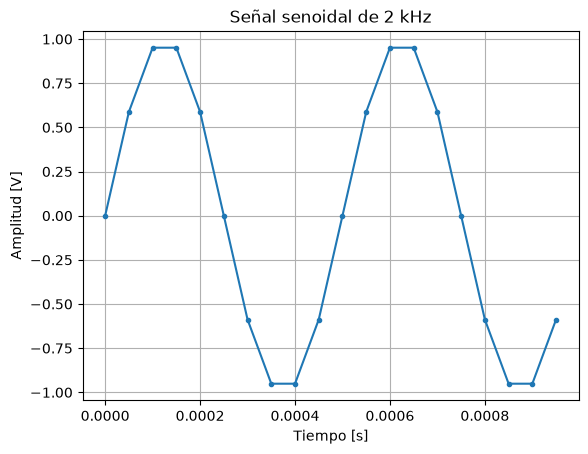

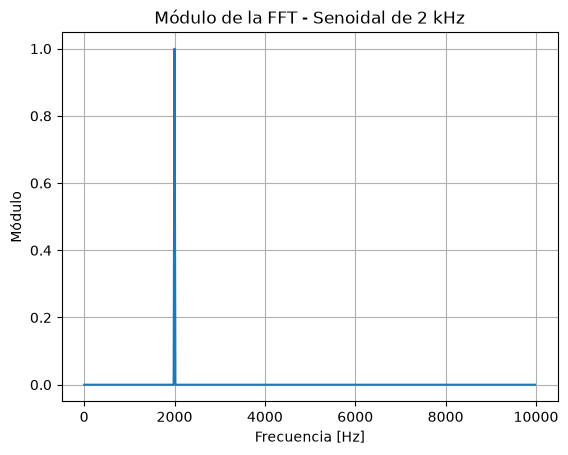

In [16]:
#%% DEF.Valores

N = 1000
fs = 20000#[Hz] definimos por inciso 1.1 para obtener 10 muestras/periodo
#%% FUNCIONES

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):

    tt = np.arange(0, nn/fs, 1/fs)

    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)

    return tt, xx


#%% EJ 1.1
# Senoidal de 2 kHz con al menos 10 muestras por período
ff = 2000#[Hz]
vmax = 1
dc = 0
ph = 0

tt, x1 = mi_funcion_sen(
    vmax=vmax,
    dc=dc,
    ff=ff,
    ph=ph,
    nn=N,
    fs=fs
)

#%% GRAFICO SENAL EN EL TIEMPO

plt.figure()
plt.plot(tt[:20], x1[:20], marker='.')#graficamos solo las primeras 20 muestras para visualizar mejor
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal senoidal de 2 kHz')
plt.grid()
plt.show()

#%% FFT

X1 = np.fft.fft(x1)#calc transformada y nos devuelve X1[k] con N valores

delta_f = fs/N #calc. resolucion frecuencial
k = np.arange(N//2)
freq = k * delta_f #frec correspondiente al bin k

mod_X1 = 2*np.abs(X1[:N//2])/N #normalizo por N y mult por 2 para recuperar amplit incicial, por qiedarme con la mitad del espectro. 

plt.figure()
plt.plot(freq, mod_X1)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.title('Módulo de la FFT - Senoidal de 2 kHz')
plt.grid()
plt.show()

En el *gráfico temporal* se observa una señal sinusoidal de amplitud aproximada de $1\,\text{V}$ y período de $0.5\,\text{ms}$. Además, pueden identificarse 10 muestras por período, de acuerdo con los parámetros establecidos. Como se representaron únicamente las primeras 20 muestras, en el gráfico se observan exactamente dos períodos completos de la señal.


Por otro lado, analizando el *módulo de la FFT* se observa un único pico significativo en:
$$f = 2000\,\text{Hz}$$ correspondiente al bin: $k = 100$.
Esto puede verificarse a partir de la resolución frecuencial:
$\Delta f = \frac{f_s}{N}= \frac{20000}{1000}= 20\,\text{Hz}$. Por lo tanto, la frecuencia correspondiente a cada bin de la DFT queda definida como: $$f_k = k \Delta f$$

Por lo tanto:

$$k = \frac{f_0}{\Delta f}= \frac{2000}{20}= 100$$

El módulo de dicho pico es aproximadamente igual a 1, coincidiendo con la amplitud de la señal sinusoidal sintetizada.

Además, prácticamente no se observan componentes en los demás bins. Esto ocurre porque la frecuencia de la señal coincide exactamente con uno de los bins de la DFT y porque dentro de la ventana de observación se registra un número entero de períodos.

En efecto, durante los $0.05\,\text{s}$ de observación se registran 100 períodos completos. Como consecuencia, la componente frecuencial queda concentrada en el bin correspondiente y no se observa fuga espectral apreciable.

### Señal sinusoidal de 2 kHz, 2 W y fase $\pi/2$

En este caso se mantuvieron los parámetros utilizados anteriormente:

$$
N = 1000
$$

$$
f_s = 20000\,\text{Hz}
$$

$$
f_0 = 2000\,\text{Hz}
$$

pero se modificaron la potencia media y la fase de la señal.

Se desea obtener una potencia media de:

$$
P = 2\,\text{W}
$$

Para una señal sinusoidal de media cero, la potencia media está dada por:

$$
P = \frac{A^2}{2}
$$

Por lo tanto:

$$
2 = \frac{A^2}{2}
$$

$$
A = 2
$$

De esta manera, se definió una amplitud máxima de:$A = 2\,\text{V}$. Y se introdujo un desfase de: $\phi = \frac{\pi}{2}$

Por lo que la señal sintetizada queda expresada como:

$$
x_2(t) =
2\sin\left(2\pi f_0t+\frac{\pi}{2}\right)
$$

con:$f_0 = 2000\,\text{Hz}$


Varianza de x2: 1.9999999999999991 W


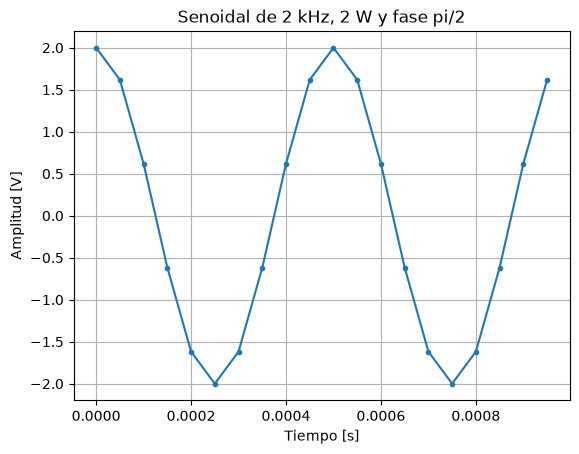

In [17]:
#%% EJ 1.2
# Misma señal, potencia media 2 W y fase pi/2

vmax2 = 2 #para que la P=2W
ph2 = np.pi/2

tt, x2 = mi_funcion_sen(
    vmax=vmax2,
    dc=0,
    ff=ff,
    ph=ph2,
    nn=N,
    fs=fs
)
#chequeamos con la varianza si la potencia media es correcta, como la media=0, deberian coincidir
var_x2 = np.var(x2) 
print("Varianza de x2:", var_x2, "W")

# GRAFICO SENAL EN EL TIEMPO

plt.figure()
plt.plot(tt[:20], x2[:20], marker='.')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Senoidal de 2 kHz, 2 W y fase pi/2')
plt.grid()
plt.show()

En principio, para verificar la potencia obtenida se calculó la *varianza* de la señal. Como su valor medio es cero, la *potencia media y la varianza coinciden*, obteniéndose un valor aproximadamente igual a:
$$P = 2\,\text{W}$$

En cuanto al *gráfico temporal*, se representaron nuevamente las primeras 20 muestras, equivalentes a dos períodos completos.

Se observa que la señal presenta una amplitud comprendida entre aproximadamente $-2\,\text{V}$ y $+2\,\text{V}$, de acuerdo con la amplitud calculada a partir de la potencia requerida.

Además, a diferencia de la señal del inciso anterior, la primera muestra comienza en el valor máximo positivo, aproximadamente $+2\,\text{V}$. Esto se debe al desfase de $\pi/2$ introducido en la señal.

Utilizando la identidad trigonométrica:

$$\sin\left(\theta+\frac{\pi}{2}\right)=\cos(\theta)$$

la señal puede escribirse de manera equivalente como:

$$x_2(t)=2\cos(2\pi f_0t)$$

Por lo tanto, para $t=0$:

$$x_2(0)=2\cos(0)=2$$

Esto explica que la señal comience en su valor máximo positivo.

En cambio, en el inciso anterior se tenía una fase inicial nula, por lo que:

$$x_1(0)=\sin(0)=0$$

La comparación entre ambos gráficos permite observar directamente el efecto del desfase sobre la representación temporal de la señal.

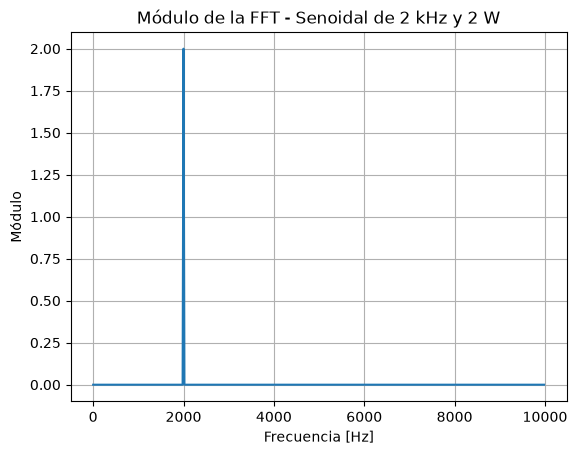

In [18]:
#FFT
X2 = np.fft.fft(x2)

mod_X2 = 2*np.abs(X2[:N//2])/N

plt.figure()
plt.plot(freq, mod_X2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.title('Módulo de la FFT - Senoidal de 2 kHz y 2 W')
plt.grid()
plt.show()

En cuanto a la FFT, al igual que en el caso anterior, debido a que la señal es real se representó únicamente la *mitad positiva del espectro*. El módulo de la FFT se normalizó dividiendo por $N$ y multiplicando por 2 para obtener el espectro unilateral y recuperar la amplitud de la señal.

Analizando el gráfico, observamos nuevamente un único pico en:
$$f = 2000\,\text{Hz}$$

correspondiente al bin:$$k = 100$$

ya que la resolución frecuencial continúa siendo $\Delta f =20\,\text{Hz}$. Y por lo tanto:

$$
k =
\frac{f_0}{\Delta f}
=
\frac{2000}{20}
=
100
$$

El pico presenta ahora un módulo aproximadamente igual a $2$, coincidiendo con la amplitud de la señal sintetizada.

Es importante observar que el desfase de $\pi/2$ *no modifica el módulo de la Transformada de Fourier*. Un cambio de fase modifica la fase de la transformada, pero no la ubicación ni el módulo de las componentes frecuenciales.

Por lo tanto, el aumento observado en el módulo del pico respecto del inciso anterior no se debe al desfase introducido, sino al aumento de la amplitud de la señal de $1\,\text{V}$ a $2\,\text{V}$.

### Ruido normalmente distribuido

Posteriormente, se generó una secuencia aleatoria de ruido normalmente distribuido, con valor medio nulo y varianza igual a 0.1 W.

Una variable aleatoria con distribución normal puede expresarse como:

$$x[n] \sim \mathcal{N}(\mu,\sigma^2)$$

donde $\mu$ representa el valor medio y $\sigma^2$ la varianza.

En este caso:

$$\mu = 0$$

$$\sigma^2 = 0.1$$

Para generar la secuencia mediante `np.random.normal`, es necesario proporcionar el desvío estándar $\sigma$ y no directamente la varianza. Por lo tanto:

$$\sigma = \sqrt{\sigma^2}= \sqrt{0.1} \approx 0.316$$

De esta manera, se generaron $N=1000$ muestras aleatorias normalmente distribuidas utilizando media cero y desvío estándar $\sqrt{0.1}$.

Como verificación, se calcularon mediante Python la media y la varianza de la secuencia obtenida. Debido a que se trabaja con una cantidad finita de muestras, los valores obtenidos no coinciden exactamente con los valores teóricos, aunque resultan próximos a ellos. 

Media medida: 0.03238220761272469
Varianza medida: 0.1047397889844218


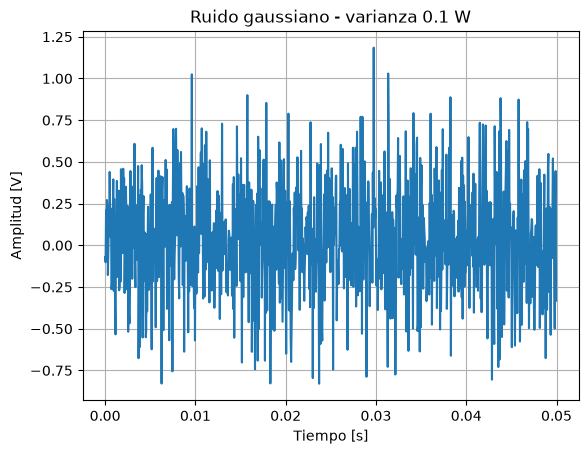

In [19]:
#%% EJ 1.3
# Ruido normalmente distribuido con media = 0 V y varianza = 0.1 W

media = 0
varianza = 0.1
sigma = np.sqrt(varianza)

ruido_gauss = np.random.normal(media,sigma,N)

print("Media medida:", np.mean(ruido_gauss))
print("Varianza medida:", np.var(ruido_gauss))

#GRAF TEMPORAL
plt.figure()
plt.plot(tt, ruido_gauss)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Ruido gaussiano - varianza 0.1 W')
plt.grid()
plt.show()


En el gráfico temporal se observa una señal irregular que fluctúa alrededor de cero, sin presentar una forma periódica definida.

Para una distribución normal, aproximadamente el $68\%$ de los valores se encuentran dentro del intervalo comprendido entre una desviación estándar por debajo y por encima de la media:

$$
\mu-\sigma \leq x[n] \leq \mu+\sigma
$$

Como en este caso $\mu=0$ y $\sigma\approx0.316$, una gran cantidad de las muestras se concentra aproximadamente entre:

$$
-0.316 \leq x[n] \leq 0.316
$$

aunque pueden aparecer valores de amplitud mayor, ya que la distribución gaussiana no se encuentra acotada.

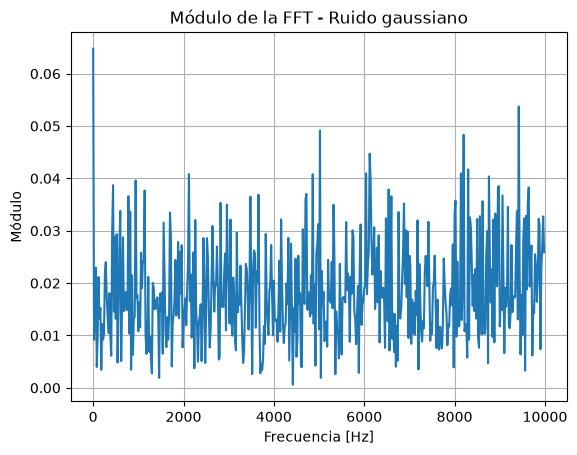

In [20]:
#FFT
R_gauss = np.fft.fft(ruido_gauss)

mod_R_gauss = 2*np.abs(R_gauss[:N//2])/N  #/N para normalizar y *2 para compensar que solo me quedo con la mitad del espectro

plt.figure()
plt.plot(freq, mod_R_gauss)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.title('Módulo de la FFT - Ruido gaussiano')
plt.grid()
plt.show()

Para estudiar el contenido frecuencial de la secuencia se calculó nuevamente la FFT. Debido a que el ruido generado es una señal real, nuevamente se representó únicamente la mitad del espectro correspondiente a frecuencias positivas.

Al igual que en los casos anteriores, el resultado de la FFT se normalizó dividiendo por $N$. Además, se utilizó un factor 2 para representar el módulo de forma unilateral, compensando la mitad negativa del espectro que no se está graficando.

A diferencia de la señal sinusoidal analizada anteriormente, en la cual prácticamente todo el contenido frecuencial se encontraba concentrado en una única frecuencia, el ruido gaussiano presenta componentes distribuidas a lo largo de todo el rango de frecuencias analizado. Ya que en el módulo de la FFT no se observa una frecuencia dominante, sino valores distribuidos de manera irregular a lo largo del espectro.

Este comportamiento es compatible con el de un ruido blanco: idealmente, su potencia se encuentra distribuida en frecuencia, sin privilegiar una componente particular.


### Ruido uniformemente distribuido
En este caso se mantuvieron el mismo valor medio y la misma varianza que en el ruido gaussiano, pero utilizando una distribución uniforme

Para una distribución uniforme definida entre los valores $a$ y $b$, la media y la varianza están dadas por:

$$\mu = \frac{a+b}{2}$$

$$\sigma^2 = \frac{(b-a)^2}{12}$$

Como se desea obtener una media igual a cero, se eligió un intervalo simétrico alrededor del origen:

$$a=-A$$

$$b=A$$

De esta manera:

$$\mu = \frac{-A+A}{2}=0$$

y la varianza resulta:

$$\sigma^2 =\frac{(2A)^2}{12}=\frac{A^2}{3}$$


Como la varianza requerida es $0.1\,\text{W}$, si despejamos A de la ecuación anterior, obtenemos:

$$A = \sqrt{0,3}\approx 0,548$$

Por lo tanto, la secuencia de ruido uniforme se generó dentro del intervalo aproximado:

$$-0,548 \leq x[n] \leq 0,548$$

Para su implementación se utilizó la función `np.random.uniform`, indicando como límite inferior $-A$, como límite superior $A$ y como longitud de la secuencia $N=1000$ muestras.

Como verificación, se calcularon nuevamente la media y la varianza de la secuencia obtenida. Nuevamente, como estamos utilizando una cantidad finita de muestras, dichos resultados no coinciden exactamente con los teóricos. A medida que aumenta la cantidad de muestras, estas estimaciones tienden a aproximarse mejor a los valores teóricos de la distribución.

Media medida: -0.014285656028384651
Varianza medida: 0.10379159191347184


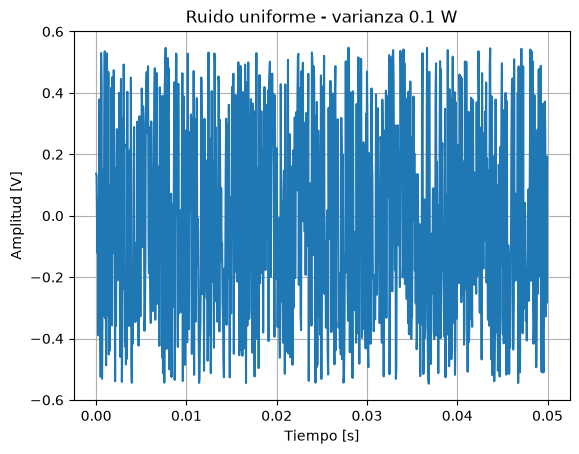

In [21]:
#%% EJ 1.4
# Ruido uniformemente distribuido con media = 0 V y varianza = 0.1 W

varianza = 0.1
A = np.sqrt(3*varianza)

ruido_uniforme = np.random.uniform(-A,A,N) #elige 1000 números al azar entre \(-A\) y \(A\).

print("Media medida:", np.mean(ruido_uniforme))
print("Varianza medida:", np.var(ruido_uniforme))

#graf en t
plt.figure()
plt.plot(tt, ruido_uniforme)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Ruido uniforme - varianza 0.1 W')
plt.grid()
plt.show()

En el gráfico temporal se observa una señal aleatoria que fluctúa alrededor de cero. A diferencia del ruido gaussiano del inciso anterior, en este caso todas las muestras permanecen acotadas dentro del intervalo definido:

$$
-0.548 \leq x[n] \leq 0.548
$$

Esto se debe a que la distribución uniforme se encuentra limitada entre $-A$ y $A$.

En cambio, la distribución gaussiana no está acotada, por lo que puede generar valores de amplitud más alejados del valor medio.

Además, en una distribución uniforme todos los valores dentro del intervalo tienen la misma probabilidad de ocurrencia, mientras que en la distribución gaussiana existe una mayor concentración de valores alrededor de la media.

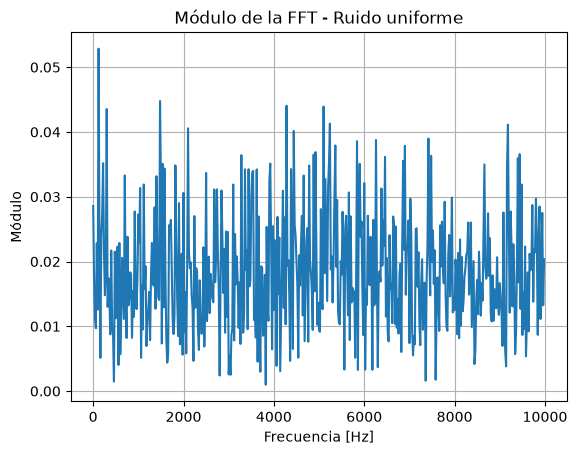

In [22]:
#FFT
R_uniforme = np.fft.fft(ruido_uniforme)

mod_R_uniforme = 2*np.abs(R_uniforme[:N//2])/N

plt.figure()
plt.plot(freq, mod_R_uniforme)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.title('Módulo de la FFT - Ruido uniforme')
plt.grid()
plt.show()

Al analizar el módulo de la FFT se observa nuevamente contenido frecuencial distribuido a lo largo de todo el rango analizado, sin una frecuencia dominante.

El comportamiento general del espectro resulta similar al obtenido para el ruido gaussiano. Esto se debe a que, aunque ambas señales presentan distribuciones de amplitud diferentes en el dominio temporal, fueron generadas como secuencias aleatorias sin una frecuencia "privilegiada" y con la misma varianza.

Como ambas señales poseen valor medio aproximadamente nulo, su potencia media puede relacionarse con la varianza:

$$
P = \sigma^2
$$

Por lo tanto, tanto el ruido gaussiano como el uniforme presentan aproximadamente la misma potencia total:

$$
P \approx 0.1\,\text{W}
$$

La principal diferencia entre ambas señales se encuentra en su distribución de amplitudes: el ruido gaussiano concentra una mayor cantidad de muestras alrededor de cero y permite la aparición de valores más alejados, mientras que el ruido uniforme asigna igual probabilidad a todos los valores comprendidos dentro del intervalo definido.

A pesar de estas diferencias en el dominio temporal, ambos espectros presentan un aspecto similar, con contenido distribuido en numerosas frecuencias y sin componentes dominantes.

### Señal rectangular de 2 kHz, 1 W y duty cycle del 50%

Seguidamente, se mantuvieron los parámetros utilizados anteriormente:

$$f_0 = 2000\,\text{Hz}$$

$$f_s = 20000\,\text{Hz}$$

$$N = 1000$$

Por lo tanto, se continúan teniendo 10 muestras por período.

Sintetizamos una señal rectangular con un ciclo de actividad (*duty cycle*) del $50\%$. Esto significa que, dentro de cada período, la señal permanece la mitad del tiempo en el nivel alto y la otra mitad en el nivel bajo.

Para sintetizarla se utilizó la función `signal.square` de `scipy.signal` con un duty cycle de: $D=0.5$

Por defecto, esta función genera una señal que toma valores entre: $+1$ y $-1$.
Como queremos que su potencia sea de 1 W, calculamos la potencia media siguiendo esta ecuación: 
$$P=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2$$

Como en este caso todas las muestras toman únicamente los valores $+1$ o $-1$, $x^2[n]=1$ para todas las muestras. Por lo tanto: $P=1\,\text{W}$


De esta manera, la señal generada ya posee la potencia solicitada y no fue necesario modificar su amplitud.


Potencia medida: 1.0 W


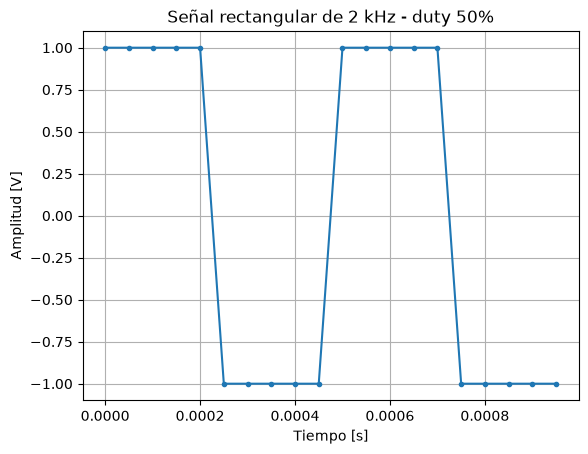

In [27]:
#%% EJ 1.5
# Pulso rectangular de 2 kHz Potencia = 1 W Duty cycle = 50 %

from scipy import signal

x5 = signal.square(2*np.pi*ff*tt, duty=0.5)

pot_x5 = np.mean(x5**2)

print("Potencia medida:", pot_x5, "W")

#grafico en t
plt.figure()
plt.plot(tt[:20], x5[:20], marker='.')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal rectangular de 2 kHz - duty 50%')
plt.grid()
plt.show()

Como verificación, se calculó la potencia a través de la función`np.mean` obteniéndose un valor igual a $1\,\text{W}$.

En cuanto al gráfico temporal, se observa que la señal alterna entre los niveles $+1\,\text{V}$ y $-1\,\text{V}$. Como se tienen 10 muestras por período y el ciclo de actividad es del $50\%$, la mitad de las muestras de cada período se encuentra en el nivel positivo y la otra mitad en el nivel negativo.

Por lo tanto, cada período queda compuesto por 5 muestras en $+1\,\text{V}$ y 5 muestras en $-1\,\text{V}$.

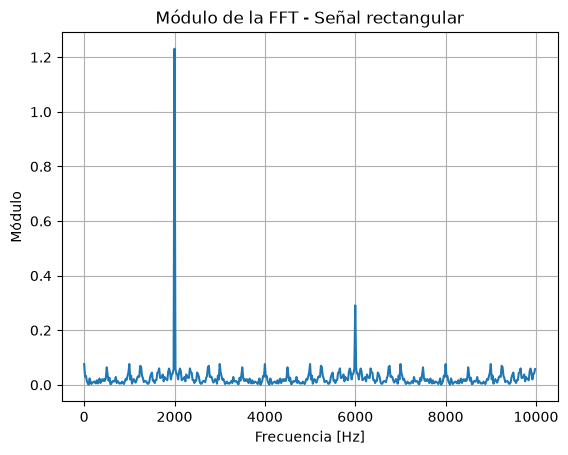

In [24]:
#fft
X5 = np.fft.fft(x5)

mod_X5 = 2*np.abs(X5[:N//2])/N

plt.figure()
plt.plot(freq, mod_X5)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.title('Módulo de la FFT - Señal rectangular')
plt.grid()
plt.show()

En cuanto al análisis espectral, a diferencia de una señal sinusoidal, una señal rectangular no contiene una única componente frecuencial. Su espectro está formado por una frecuencia fundamental y distintos armónicos.

Para una señal rectangular simétrica, de valor medio nulo y duty cycle del $50\%$, aparecen armónicos impares de la frecuencia fundamental:

$$f_0,\;3f_0,\;5f_0,\;7f_0,\dots$$

Como:

$$f_0=2000\,\text{Hz}$$

las primeras componentes esperadas son:

$$f_0=2000\,\text{Hz}$$

$$3f_0=6000\,\text{Hz}$$

$$5f_0=10000\,\text{Hz}$$

La frecuencia de Nyquist para este sistema es:

$$f_N=\frac{f_s}{2}=\frac{20000}{2}=10000\,\text{Hz}$$


Por lo tanto, dentro del rango representable sin aliasing se encuentran la componente fundamental en $2000\,\text{Hz}$, el tercer armónico en $6000\,\text{Hz}$ y el quinto armónico se ubicaría justo en la frecuencia de Nyquist.

En el módulo de la FFT se observa que la componente de mayor amplitud corresponde a la frecuencia fundamental:

$$
f_0=2000\,\text{Hz}
$$

También puede identificarse una componente de menor amplitud alrededor de:

$$
6000\,\text{Hz}
$$

correspondiente al tercer armónico.

Los armónicos de una señal rectangular disminuyen progresivamente en amplitud a medida que aumenta su orden. Por este motivo, la componente fundamental es la dominante y los armónicos superiores presentan amplitudes menores.

## Bonus
### Señal triangular

Como señal adicional disponible en `scipy.signal` se implementó una señal triangular utilizando la función `signal.sawtooth` con `width=0.5`, lo que genera una forma triangular simétrica.

Se mantuvieron los parámetros utilizados en los incisos anteriores:

$$
f_0 = 2000\,\text{Hz}
$$

$$
f_s = 20000\,\text{Hz}
$$

$$
N = 1000
$$


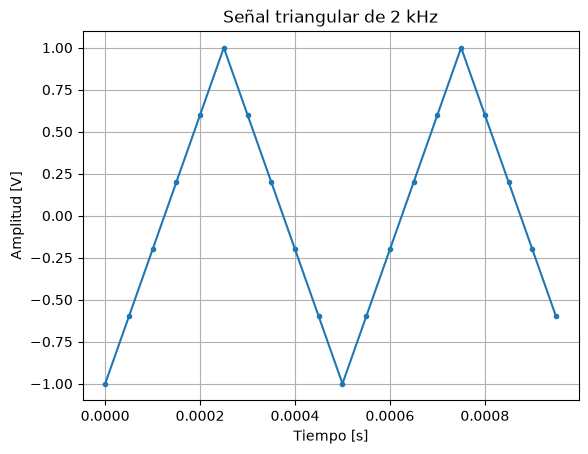

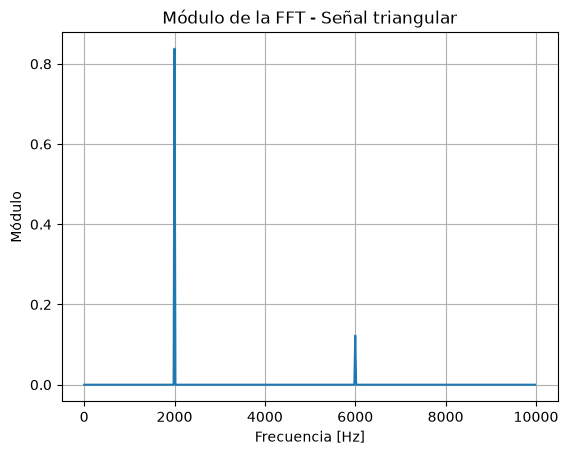

In [28]:
#%% BONUS - Señal triangular

x_bonus = signal.sawtooth(
    2*np.pi*ff*tt,
    width=0.5
)

plt.figure()
plt.plot(tt[:20], x_bonus[:20], marker='.')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title('Señal triangular de 2 kHz')
plt.grid()
plt.show()

# FFT
X_bonus = np.fft.fft(x_bonus)

mod_X_bonus = 2*np.abs(X_bonus[:N//2])/N

plt.figure()
plt.plot(freq, mod_X_bonus)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo')
plt.title('Módulo de la FFT - Señal triangular')
plt.grid()
plt.show()

En el dominio temporal se observa una señal triangular simétrica, con amplitud comprendida aproximadamente entre $-1\,\text{V}$ y $+1\,\text{V}$.

Al analizar el módulo de su FFT se observa una componente fundamental en:

$$
f_0 = 2000\,\text{Hz}
$$

y una componente de menor amplitud en:

$$
3f_0 = 6000\,\text{Hz}
$$

correspondiente al tercer armónico.

Al igual que en la señal rectangular de duty cycle del $50\%$, la señal triangular presenta principalmente armónicos impares:

$$
f_0,\;3f_0,\;5f_0,\dots
$$

Sin embargo, en la señal triangular la amplitud de los armónicos decrece más rápidamente con el orden del armónico, aproximadamente según:

$$
\frac{1}{n^2}
$$

mientras que para una señal rectangular ideal el decrecimiento es aproximadamente:

$$
\frac{1}{n}
$$

Por este motivo, en el espectro de la señal triangular los armónicos superiores presentan una amplitud considerablemente menor respecto de la componente fundamental.

### Cálculo de potencia mediante el Teorema de Parseval

El Teorema de Parseval permite relacionar la energía de una señal en el dominio temporal con la energía contenida en su representación frecuencial.

Para una secuencia discreta de longitud $N$, la DFT cumple:

$$
\sum_{n=0}^{N-1}|x[n]|^2
=
\frac{1}{N}
\sum_{k=0}^{N-1}|X[k]|^2
$$

La potencia media de la señal en el dominio temporal se calcula como:

$$
P=
\frac{1}{N}
\sum_{n=0}^{N-1}|x[n]|^2
$$

Aplicando el Teorema de Parseval:

$$
P=
\frac{1}{N^2}
\sum_{k=0}^{N-1}|X[k]|^2
$$

Por lo tanto, la potencia de una señal también puede calcularse a partir de su Transformada Discreta de Fourier.

En Python, utilizando la FFT completa, esto puede implementarse como:

`pot_frec = np.sum(np.abs(X)**2) / N**2`

Para comprobar el Teorema de Parseval, se aplicó esta relación a la señal sinusoidal de $2\,\text{kHz}$, $2\,\text{W}$ y fase $ \pi/2$, mediante el siguiente código:

In [29]:
#%% BONUS - Potencia mediante Parseval

# Potencia calculada en el tiempo
pot_tiempo = np.mean(x2**2)

# FFT completa
X2 = np.fft.fft(x2)

# Potencia calculada mediante Parseval
pot_frec = np.sum(np.abs(X2)**2) / N**2

print("Potencia en el tiempo:", pot_tiempo, "W")
print("Potencia mediante FFT:", pot_frec, "W")

Potencia en el tiempo: 1.9999999999999991 W
Potencia mediante FFT: 2.0000000000000004 W


Los resultados obtenidos verifican el Teorema de Parseval, ya que la potencia calculada en el dominio temporal coincide con la obtenida mediante la FFT. 

## Conclusión

A lo largo del trabajo se sintetizaron y analizaron distintas señales en los dominios temporal y frecuencial utilizando $N=1000$ muestras.

A partir de la señal sinusoidal se observó que la amplitud de la señal modifica el módulo de su FFT, mientras que un cambio de fase altera la forma temporal y la fase de la transformada, pero no la ubicación de sus componentes frecuenciales.

El análisis de las secuencias de ruido permitió comparar distribuciones gaussianas y uniformes. Aunque ambas señales presentaban comportamientos diferentes en el dominio temporal, ambas fueron generadas con la misma media, varianza y potencia, y presentaron un contenido frecuencial distribuido a lo largo del espectro sin una frecuencia dominante.

En el caso de las señales rectangular y triangular se observó que una señal periódica no sinusoidal puede descomponerse en una componente fundamental y armónicos. Además, se comprobó que la forma temporal de la señal influye directamente en la distribución y amplitud de dichos armónicos.

Finalmente, mediante el Teorema de Parseval se verificó que la potencia de una señal puede calcularse tanto en el dominio temporal como a partir de su Transformada de Fourier, obteniéndose resultados equivalentes.

## Ejercicio 2
Adjunto pdf del ejercicio resuelto con su respectivo bonus. 

[Ver resolución del Ejercicio 2](ej2_ts1_hoffenreich.pdf)